In [1]:
# phase2_MMI_sweep.py
# MEEP 3D FDTD: sweep MMI length for 50/50 splitting at 1550 nm
# Reference geometry: [R6], waveguide from Phase 1

import meep as mp
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

Using MPI version 4.1, 1 processes


In [2]:

# ── Units: µm, c = 1 ───────────────────────────────────────────────────────
lam = 1.55
f0  = 1.0 / lam
df  = 0.15 / lam   # source bandwidth

# ── Materials ───────────────────────────────────────────────────────────────
LNO  = mp.Medium(epsilon_diag=mp.Vector3(2.138**2, 2.211**2, 2.211**2))
SiO2 = mp.Medium(index=1.444)


# ── Material indices at 1550 nm (Zelmon et al. 1997 [R5]) ──────────────────
n_e  = 2.138   # LNO extraordinary (TE mode, X-cut: c-axis along x)
n_o  = 2.211   # LNO ordinary
n_ox = 1.444   # SiO₂ BOX
n_air = 1.0

In [3]:

# ── Fixed geometry parameters ───────────────────────────────────────────────
h       = 0.30    # LNO core height
wg_w    = 0.90    # input/output waveguide width
W_MMI   = 5.5     # MMI body width (sweep W in a second pass if needed)
taper_L = 2.0     # linear taper length (wg_w → W_MMI at port)
port_off = W_MMI / 4  # = 1.375 µm — paired interference offset from center [R6]
pml_d   = 1.5     # PML thickness (µm)
wg_len  = 3.0     # input/output waveguide stub length beyond taper


In [4]:

def build_geometry(L_mmi, sx, sy, sz):
    """Build MEEP geometry list for 2×2 MMI with given body length."""
    x_mmi_c = 0.0    # MMI center at x = 0
    half_L  = L_mmi / 2

    geom = []

    # SiO₂ BOX (below LNO)
    geom.append(mp.Block(
        size=mp.Vector3(sx, sy, 2.0),
        center=mp.Vector3(0, 0, -(h/2 + 1.0)),
        material=SiO2
    ))

    # ── Input side (x < -half_L) ─────────────────────────────────────────
    # Upper input waveguide stub + taper
    x_in_wg_start = -(half_L + taper_L + wg_len)
    # Waveguide stub
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, +port_off, 0),
        material=LNO
    ))
    # Taper (approximated as block at full width — for accuracy use TrapezoidBlock
    # or break into small steps; sufficient for sweep at res=20)
    geom.append(mp.Block(
        size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
        center=mp.Vector3(-half_L - taper_L/2, +port_off/2, 0),
        material=LNO
    ))

    # Lower input waveguide (unused input port — terminated, or add second source)
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, -port_off, 0),
        material=LNO
    ))

    # ── MMI body ─────────────────────────────────────────────────────────
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI, h),
        center=mp.Vector3(0, 0, 0),
        material=LNO
    ))

    # ── Output side (x > +half_L) ─────────────────────────────────────────
    for sign in [+1, -1]:
        # Taper
        geom.append(mp.Block(
            size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
            center=mp.Vector3(+half_L + taper_L/2, sign * port_off/2, 0),
            material=LNO
        ))
        # Output waveguide stub
        geom.append(mp.Block(
            size=mp.Vector3(wg_len, wg_w, h),
            center=mp.Vector3(+half_L + taper_L + wg_len/2, sign * port_off, 0),
            material=LNO
        ))

    return geom



In [5]:
def run_mmi_sim(L_mmi, resolution=10):   # ← resolution 10, not 5
    stub = 4.0
    total_x = pml_d + stub + L_mmi + stub + pml_d
    sy_cell  = W_MMI + 6.0 + 2 * pml_d  # ← more padding around MMI

    cell    = mp.Vector3(total_x, sy_cell)
    half_tx = total_x / 2

    x_mmi_left  = -L_mmi / 2
    x_mmi_right = +L_mmi / 2

    geom = []

    # MMI body
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI),
        center=mp.Vector3(0, 0),
        material=LNO,
    ))

    # BOTH input stubs — upper and lower
    for sign in [+1, -1]:
        geom.append(mp.Block(
            size=mp.Vector3(stub + pml_d, wg_w),
            center=mp.Vector3(x_mmi_left - (stub + pml_d)/2, sign * port_off),
            material=LNO,
        ))

    # Both output stubs
    for sign in [+1, -1]:
        geom.append(mp.Block(
            size=mp.Vector3(stub + pml_d, wg_w),
            center=mp.Vector3(x_mmi_right + (stub + pml_d)/2, sign * port_off),
            material=LNO,
        ))

    # Source placed well inside the upper input stub, away from MMI edge
    x_src = x_mmi_left - stub + 1.0    # ← 1 µm inside the stub, not 0.5
    src = [mp.EigenModeSource(
        src=mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, +port_off),
        size=mp.Vector3(0, wg_w + 0.5),  # ← tighter source, only 0.25 µm beyond wg edge
        eig_band=1,
        eig_parity=mp.NO_PARITY,
        direction=mp.X,
    )]

    x_mon = x_mmi_right + stub - 1.0   # ← monitor also pulled away from MMI edge
    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),
    )

    flux_upper = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, +port_off),
            size=mp.Vector3(0, wg_w + 0.5)
        ))
    flux_lower = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, -port_off),
            size=mp.Vector3(0, wg_w + 0.5)
        ))

    sim.run(until_after_sources=300)

    T_upper = mp.get_fluxes(flux_upper)[0]
    T_lower = mp.get_fluxes(flux_lower)[0]
    sim.reset_meep()
    return T_upper, T_lower

In [6]:
# ── Reference simulation (straight waveguide, for normalization) ──────────
###################### 2D #################################
def run_reference(resolution=5):
    ref_len = 20.0
    total_x = pml_d + wg_len + ref_len + wg_len + pml_d
    sy_c = wg_w + 3.0 + 2 * pml_d

    cell = mp.Vector3(total_x, sy_c)
    half_tx = total_x / 2
    x_src = -half_tx + pml_d + 0.5
    x_mon = +half_tx - pml_d - 0.5

    geom = [
        mp.Block(
            size=mp.Vector3(total_x, wg_w),
            center=mp.Vector3(0, 0),
            material=LNO
        ),
    ]

    src = [mp.EigenModeSource(
        mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, 0),
        size=mp.Vector3(0, wg_w + 1.5),
        eig_band=1,
        eig_parity=mp.ODD_Y,
        direction=mp.X,
    )]

    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),
    )

    flux = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, 0),
            size=mp.Vector3(0, wg_w + 1.0)
        ))

    sim.run(until_after_sources=500)  #hard cap

    P_ref = mp.get_fluxes(flux)[0]
    sim.reset_meep()
    return P_ref

In [7]:

# ── Main sweep ─────────────────────────────────────────────────────────────
print("Running reference simulation...")
P_ref = run_reference(resolution=20)
print(f"P_ref = {P_ref:.6f}")

# L_sweep = np.arange(10, 56, 2)   # coarse: 10 to 54 µm in 2 µm steps
# L_sweep = np.arange(30, 85, 5)   # coarser steps, wider range, fewer points
# L_sweep = np.arange(28, 50, 2)   # 11 points, focused on the real peak
L_sweep = np.arange(28, 75, 3)   # 28, 31, 34 ... 73 → 16 points
# fine sweep around the crossing point
# L_sweep_fine = np.arange(L_cross - 4, L_cross + 4, 0.5)  # 16 points, 0.5 µm steps
T_upper_list, T_lower_list = [], []

print(f"\n{'L (µm)':>8}  {'T_upper':>9}  {'T_lower':>9}  {'T_total':>9}  {'ratio':>7}")
for L in L_sweep:
    tu, tl = run_mmi_sim(L, resolution=20)
    tu_norm = tu / P_ref
    tl_norm = tl / P_ref
    tt = tu_norm + tl_norm
    ratio = tu_norm / tt if tt > 0 else 0
    T_upper_list.append(tu_norm)
    T_lower_list.append(tl_norm)
    print(f"{L:>8.0f}  {tu_norm:>9.4f}  {tl_norm:>9.4f}  {tt:>9.4f}  {ratio:>7.3f}")

T_upper = np.array(T_upper_list)
T_lower = np.array(T_lower_list)
T_total = T_upper + T_lower
imbalance = np.abs(T_upper - T_lower)

# Candidate points: high total T and low imbalance
valid = T_total > 0.80 * np.max(T_total)
if valid.any():
    best_idx = np.argmin(imbalance[valid])
    best_L = L_sweep[valid][best_idx]
    print(f"\nCoarse optimum: L ≈ {best_L} µm")
    print(f"At best_L: T_upper={T_upper[valid][best_idx]:.4f}, "
          f"T_lower={T_lower[valid][best_idx]:.4f}")
else:
    print("No optimum found in sweep range — extend range!")
    best_L = None


Running reference simulation...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000290572 s
Working in 2D dimensions.
Computational cell is 29 x 6.9 x 0 with resolution 20
     block, center = (0,0,0)
          size (29,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
time for set_epsilon = 0.139543 s
-----------
MPB solved for frequency_1(1.41022,0,0) = 0.676616 after 16 iters
MPB solved for frequency_1(1.33778,0,0) = 0.645199 after 7 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 1 iters
Meep progress: 138.35/603.3333358764648 = 22.9% done in 4.0s, 13.4s to go
on time step 5534 (time=138.35), 0.000722876 s/step
Meep progress: 281.45/603.3333358764648 = 46.6% done in 8.0s, 9.2s to go
on time step 11259 (time=281.475), 0.000698774 s/step
Meep progress: 422.95000000000005/603.3333358764648 = 70.1% done in 12.0s

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 59.6/403.33333587646484 = 14.8% done in 4.0s, 23.1s to go
on time step 2384 (time=59.6), 0.00167822 s/step
Meep progress: 123.47500000000001/403.33333587646484 = 30.6% done in 8.0s, 18.1s to go
on time step 4939 (time=123.475), 0.00156567 s/step
Meep progress: 187.35000000000002/403.33333587646484 = 46.5% done in 12.0s, 13.8s to go
on time step 7494 (time=187.35), 0.00156574 s/step
Meep progress: 251.35000000000002/403.33333587646484 = 62.3% done in 16.0s, 9.7s to go
on time step 10054 (time=251.35), 0.00156253 s/step
Meep progress: 310.0/403.33333587646484 = 76.9% done in 20.0s, 6.0s to go
on time step 12400 (time=310), 0.00170522 s/step
Meep progress: 372.6/403.33333587646484 = 92.4% done in 24.0s, 2.0s to go
on time step 14905 (time=372.625), 0.00159765 s/step
run 0 finished a

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 56.7/403.33333587646484 = 14.1% done in 4.0s, 24.5s to go
on time step 2268 (time=56.7), 0.00176407 s/step
Meep progress: 114.80000000000001/403.33333587646484 = 28.5% done in 8.0s, 20.1s to go
on time step 4593 (time=114.825), 0.00172102 s/step
Meep progress: 172.625/403.33333587646484 = 42.8% done in 12.0s, 16.0s to go
on time step 6906 (time=172.65), 0.00173032 s/step
Meep progress: 234.375/403.33333587646484 = 58.1% done in 16.0s, 11.5s to go
on time step 9377 (time=234.425), 0.00161899 s/step
Meep progress: 293.77500000000003/403.33333587646484 = 72.8% done in 20.0s, 7.5s to go
on time step 11754 (time=293.85), 0.00168317 s/step
Meep progress: 354.1/403.33333587646484 = 87.8% done in 24.0s, 3.3s to go
on time step 14167 (time=354.175), 0.00165775 s/step
run 0 finished at t =

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 53.575/403.33333587646484 = 13.3% done in 4.0s, 26.1s to go
on time step 2143 (time=53.575), 0.00186662 s/step
Meep progress: 110.525/403.33333587646484 = 27.4% done in 8.0s, 21.2s to go
on time step 4422 (time=110.55), 0.00175571 s/step
Meep progress: 165.65/403.33333587646484 = 41.1% done in 12.0s, 17.2s to go
on time step 6628 (time=165.7), 0.00181396 s/step
Meep progress: 220.775/403.33333587646484 = 54.7% done in 16.0s, 13.2s to go
on time step 8831 (time=220.775), 0.00181577 s/step
Meep progress: 271.8/403.33333587646484 = 67.4% done in 20.0s, 9.7s to go
on time step 10872 (time=271.8), 0.00196045 s/step
Meep progress: 327.40000000000003/403.33333587646484 = 81.2% done in 24.0s, 5.6s to go
on time step 13096 (time=327.4), 0.00179928 s/step
Meep progress: 382.225/403.3333358

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 49.875/403.33333587646484 = 12.4% done in 4.0s, 28.4s to go
on time step 1995 (time=49.875), 0.00200545 s/step
Meep progress: 101.95/403.33333587646484 = 25.3% done in 8.0s, 23.7s to go
on time step 4079 (time=101.975), 0.00192023 s/step
Meep progress: 152.32500000000002/403.33333587646484 = 37.8% done in 12.0s, 19.8s to go
on time step 6095 (time=152.375), 0.00198497 s/step
Meep progress: 203.55/403.33333587646484 = 50.5% done in 16.0s, 15.7s to go
on time step 8144 (time=203.6), 0.00195256 s/step
Meep progress: 254.70000000000002/403.33333587646484 = 63.1% done in 20.0s, 11.7s to go
on time step 10191 (time=254.775), 0.00195493 s/step
Meep progress: 306.02500000000003/403.33333587646484 = 75.9% done in 24.0s, 7.6s to go
on time step 12244 (time=306.1), 0.00194881 s/step
Meep pr

...

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 31.625/403.33333587646484 = 7.8% done in 4.0s, 47.0s to go
on time step 1265 (time=31.625), 0.00316431 s/step
Meep progress: 63.7/403.33333587646484 = 15.8% done in 8.0s, 42.7s to go
on time step 2549 (time=63.725), 0.00311778 s/step
Meep progress: 95.275/403.33333587646484 = 23.6% done in 12.0s, 38.8s to go
on time step 3812 (time=95.3), 0.00316728 s/step
Meep progress: 127.375/403.33333587646484 = 31.6% done in 16.0s, 34.7s to go
on time step 5096 (time=127.4), 0.0031177 s/step
Meep progress: 160.375/403.33333587646484 = 39.8% done in 20.0s, 30.3s to go
on time step 6416 (time=160.4), 0.00303057 s/step
Meep progress: 192.65/403.33333587646484 = 47.8% done in 24.0s, 26.3s to go
on time step 7707 (time=192.675), 0.00309843 s/step
Meep progress: 225.25/403.33333587646484 = 55.8% d

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 30.35/403.33333587646484 = 7.5% done in 4.0s, 49.2s to go
on time step 1214 (time=30.35), 0.00329515 s/step
Meep progress: 61.95/403.33333587646484 = 15.4% done in 8.0s, 44.1s to go
on time step 2478 (time=61.95), 0.00316649 s/step
Meep progress: 93.4/403.33333587646484 = 23.2% done in 12.0s, 39.8s to go
on time step 3736 (time=93.4), 0.0031808 s/step
Meep progress: 124.45/403.33333587646484 = 30.9% done in 16.0s, 35.9s to go
on time step 4978 (time=124.45), 0.00322245 s/step
Meep progress: 155.95000000000002/403.33333587646484 = 38.7% done in 20.0s, 31.7s to go
on time step 6238 (time=155.95), 0.00317641 s/step
Meep progress: 186.775/403.33333587646484 = 46.3% done in 24.0s, 27.8s to go
on time step 7471 (time=186.775), 0.00324423 s/step
Meep progress: 218.15/403.33333587646484 

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 28.975/403.33333587646484 = 7.2% done in 4.0s, 51.7s to go
on time step 1159 (time=28.975), 0.00345317 s/step
Meep progress: 58.775000000000006/403.33333587646484 = 14.6% done in 8.0s, 46.9s to go
on time step 2352 (time=58.8), 0.00335535 s/step
Meep progress: 88.4/403.33333587646484 = 21.9% done in 12.0s, 42.8s to go
on time step 3537 (time=88.425), 0.0033757 s/step
Meep progress: 118.275/403.33333587646484 = 29.3% done in 16.0s, 38.6s to go
on time step 4732 (time=118.3), 0.00334831 s/step
Meep progress: 148.25/403.33333587646484 = 36.8% done in 20.0s, 34.4s to go
on time step 5931 (time=148.275), 0.00333722 s/step
Meep progress: 177.65/403.33333587646484 = 44.0% done in 24.0s, 30.5s to go
on time step 7107 (time=177.675), 0.00340311 s/step
Meep progress: 206.425/403.3333358764

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 27.975/403.33333587646484 = 6.9% done in 4.0s, 53.7s to go
on time step 1119 (time=27.975), 0.00357736 s/step
Meep progress: 56.45/403.33333587646484 = 14.0% done in 8.0s, 49.2s to go
on time step 2258 (time=56.45), 0.00351474 s/step
Meep progress: 85.4/403.33333587646484 = 21.2% done in 12.0s, 44.7s to go
on time step 3416 (time=85.4), 0.00345666 s/step
Meep progress: 114.22500000000001/403.33333587646484 = 28.3% done in 16.0s, 40.5s to go
on time step 4569 (time=114.225), 0.00347028 s/step
Meep progress: 142.3/403.33333587646484 = 35.3% done in 20.0s, 36.7s to go
on time step 5692 (time=142.3), 0.00356249 s/step
Meep progress: 171.47500000000002/403.33333587646484 = 42.5% done in 24.0s, 32.5s to go
on time step 6859 (time=171.475), 0.00342881 s/step
Meep progress: 200.125/403.3

MPB solved for frequency_1(1.41022,0,0) = 0.664997 after 28 iters
MPB solved for frequency_1(1.3657,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36571,0,0) = 0.645161 after 2 iters
Meep progress: 26.475/403.33333587646484 = 6.6% done in 4.0s, 56.9s to go
on time step 1059 (time=26.475), 0.00377759 s/step
Meep progress: 54.2/403.33333587646484 = 13.4% done in 8.0s, 51.5s to go
on time step 2168 (time=54.2), 0.00360723 s/step
Meep progress: 82.15/403.33333587646484 = 20.4% done in 12.0s, 46.9s to go
on time step 3286 (time=82.15), 0.00357952 s/step
Meep progress: 109.22500000000001/403.33333587646484 = 27.1% done in 16.0s, 43.1s to go
on time step 4369 (time=109.225), 0.00369561 s/step
Meep progress: 136.75/403.33333587646484 = 33.9% done in 20.0s, 39.0s to go
on time step 5470 (time=136.75), 0.00363596 s/step
Meep progress: 164.175/403.33333587646484 = 40.7% done in 24.0s, 35.0s to go
on time step 6567 (time=164.175), 0.00364856 s/step
Meep progress: 192.35000000000002/403

In [8]:
# ── Fine sweep around best_L ────────────────────────────────────────────────
if best_L is not None:
    L_fine = np.linspace(best_L - 3, best_L + 3, 13)
    Tu_fine, Tl_fine = [], []
    for L in L_fine:
        tu, tl = run_mmi_sim(L, resolution=35)  # higher res for accuracy
        Tu_fine.append(tu / P_ref)
        Tl_fine.append(tl / P_ref)
    Tu_fine = np.array(Tu_fine)
    Tl_fine = np.array(Tl_fine)
    best_fine_idx = np.argmin(np.abs(Tu_fine - Tl_fine))
    L_opt = L_fine[best_fine_idx]
    IL_dB = -10 * np.log10(Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    split_pct = 100 * Tu_fine[best_fine_idx] / (Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    print(f"\nFine optimum: L_opt = {L_opt:.2f} µm")
    print(f"Split ratio: {split_pct:.1f}% / {100-split_pct:.1f}%")
    print(f"Insertion loss: {IL_dB:.2f} dB")
else:
    L_opt = None


-----------
Initializing structure...
time for choose_chunkdivision = 0.000914136 s
Working in 2D dimensions.
Computational cell is 81 x 14.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (70,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-37.75,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-37.75,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (37.75,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (37.75,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          di

MPB solved for frequency_1(1.41022,0,0) = 0.665194 after 24 iters
MPB solved for frequency_1(1.36526,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36527,0,0) = 0.645161 after 2 iters
Meep progress: 4.957142857142857/403.33333587646484 = 1.2% done in 4.0s, 322.1s to go
on time step 347 (time=4.95714), 0.0115519 s/step
Meep progress: 10.314285714285713/403.33333587646484 = 2.6% done in 8.0s, 305.3s to go
on time step 722 (time=10.3143), 0.010673 s/step
Meep progress: 15.714285714285714/403.33333587646484 = 3.9% done in 12.0s, 296.5s to go
on time step 1100 (time=15.7143), 0.0106075 s/step
Meep progress: 21.114285714285714/403.33333587646484 = 5.2% done in 16.0s, 290.1s to go
on time step 1478 (time=21.1143), 0.0105901 s/step
Meep progress: 26.414285714285715/403.33333587646484 = 6.5% done in 20.0s, 285.9s to go
on time step 1849 (time=26.4143), 0.0108004 s/step
Meep progress: 31.7/403.33333587646484 = 7.9% done in 24.0s, 281.8s to go
on time step 2219 (time=31.7), 0.0108202 

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000918334 s
Working in 2D dimensions.
Computational cell is 81.5143 x 14.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (70.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-38,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-38,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (38,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (38,-1.375,0)
          size (5.5,0.9,0)

MPB solved for frequency_1(1.41022,0,0) = 0.665194 after 24 iters
MPB solved for frequency_1(1.36526,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36527,0,0) = 0.645161 after 2 iters
Meep progress: 5.0/403.33333587646484 = 1.2% done in 4.0s, 319.2s to go
on time step 350 (time=5), 0.0114492 s/step
Meep progress: 10.414285714285715/403.33333587646484 = 2.6% done in 8.0s, 302.2s to go
on time step 729 (time=10.4143), 0.0105597 s/step
Meep progress: 15.799999999999999/403.33333587646484 = 3.9% done in 12.0s, 294.7s to go
on time step 1106 (time=15.8), 0.0106205 s/step
Meep progress: 21.185714285714283/403.33333587646484 = 5.3% done in 16.0s, 288.9s to go
on time step 1483 (time=21.1857), 0.0106168 s/step
Meep progress: 26.67142857142857/403.33333587646484 = 6.6% done in 20.0s, 282.8s to go
on time step 1867 (time=26.6714), 0.0104294 s/step
Meep progress: 32.1/403.33333587646484 = 8.0% done in 24.0s, 277.8s to go
on time step 2247 (time=32.1), 0.0105286 s/step
Meep progress: 3

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000908075 s
Working in 2D dimensions.
Computational cell is 82 x 14.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (71,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-38.25,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-38.25,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (38.25,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (38.25,-1.375,0)
          size (5.5,0

...

MPB solved for frequency_1(1.41022,0,0) = 0.665194 after 24 iters
MPB solved for frequency_1(1.36526,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36527,0,0) = 0.645161 after 2 iters
Meep progress: 4.571428571428571/403.33333587646484 = 1.1% done in 4.0s, 349.3s to go
on time step 320 (time=4.57143), 0.012515 s/step
Meep progress: 9.585714285714285/403.33333587646484 = 2.4% done in 8.0s, 329.0s to go
on time step 671 (time=9.58571), 0.0114064 s/step
Meep progress: 14.542857142857143/403.33333587646484 = 3.6% done in 12.0s, 321.1s to go
on time step 1018 (time=14.5429), 0.0115289 s/step
Meep progress: 19.514285714285712/403.33333587646484 = 4.8% done in 16.0s, 315.0s to go
on time step 1366 (time=19.5143), 0.0115158 s/step
Meep progress: 24.57142857142857/403.33333587646484 = 6.1% done in 20.0s, 308.6s to go
on time step 1720 (time=24.5714), 0.0113131 s/step
Meep progress: 29.485714285714284/403.33333587646484 = 7.3% done in 24.0s, 304.6s to go
on time step 2065 (time=29.5)

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000952889 s
Working in 2D dimensions.
Computational cell is 86.5143 x 14.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (75.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-40.5,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-40.5,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (40.5,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (40.5,-1.375,0)
          size (5.

MPB solved for frequency_1(1.41022,0,0) = 0.665194 after 24 iters
MPB solved for frequency_1(1.36526,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36527,0,0) = 0.645161 after 2 iters
Meep progress: 4.742857142857143/403.33333587646484 = 1.2% done in 4.0s, 336.8s to go
on time step 332 (time=4.74286), 0.0120703 s/step
Meep progress: 9.942857142857143/403.33333587646484 = 2.5% done in 8.0s, 317.1s to go
on time step 696 (time=9.94286), 0.0110101 s/step
Meep progress: 15.028571428571428/403.33333587646484 = 3.7% done in 12.0s, 310.5s to go
on time step 1053 (time=15.0429), 0.0112349 s/step
Meep progress: 20.157142857142855/403.33333587646484 = 5.0% done in 16.0s, 304.5s to go
on time step 1412 (time=20.1714), 0.011156 s/step
Meep progress: 25.142857142857142/403.33333587646484 = 6.2% done in 20.0s, 301.2s to go
on time step 1761 (time=25.1571), 0.0114698 s/step
Meep progress: 30.2/403.33333587646484 = 7.5% done in 24.0s, 296.9s to go
on time step 2115 (time=30.2143), 0.011309

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000946898 s
Working in 2D dimensions.
Computational cell is 87 x 14.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (76,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-40.75,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-40.75,-1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (40.75,1.375,0)
          size (5.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (40.75,-1.375,0)
          size (5.5,0

MPB solved for frequency_1(1.41022,0,0) = 0.665194 after 24 iters
MPB solved for frequency_1(1.36526,0,0) = 0.645156 after 7 iters
MPB solved for frequency_1(1.36527,0,0) = 0.645161 after 2 iters
Meep progress: 4.714285714285714/403.33333587646484 = 1.2% done in 4.0s, 338.8s to go
on time step 330 (time=4.71429), 0.0121439 s/step
Meep progress: 9.742857142857142/403.33333587646484 = 2.4% done in 8.0s, 323.7s to go
on time step 682 (time=9.74286), 0.0113746 s/step
Meep progress: 14.7/403.33333587646484 = 3.6% done in 12.0s, 317.7s to go
on time step 1029 (time=14.7), 0.011543 s/step
Meep progress: 19.7/403.33333587646484 = 4.9% done in 16.0s, 312.1s to go
on time step 1379 (time=19.7), 0.0114551 s/step
Meep progress: 24.71428571428571/403.33333587646484 = 6.1% done in 20.0s, 306.9s to go
on time step 1730 (time=24.7143), 0.0114043 s/step
Meep progress: 29.642857142857142/403.33333587646484 = 7.3% done in 24.0s, 303.0s to go
on time step 2075 (time=29.6429), 0.0116068 s/step
Meep progres

In [9]:


# ── Save ─────────────────────────────────────────────────────────────────────
scipy.io.savemat('MMI_transmission_3.mat', {
    'L_sweep': L_sweep,
    'T_upper': T_upper, 'T_lower': T_lower, 'T_total': T_total,
    'L_opt': L_opt if L_opt else 0,
})
print("\nSaved: MMI_transmission_3.mat")




Saved: MMI_transmission_3.mat


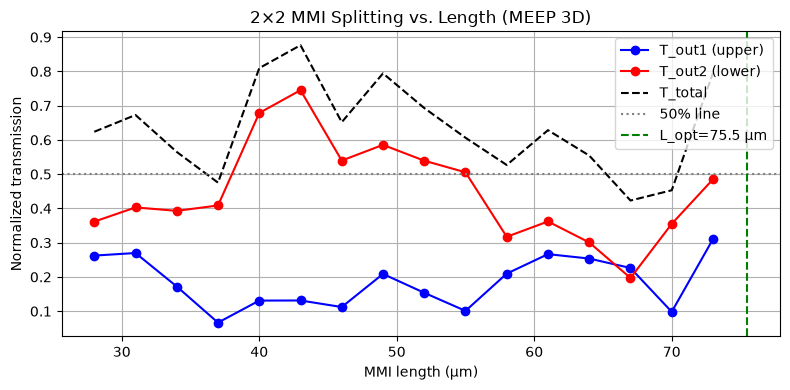

In [10]:
# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(L_sweep, T_upper, 'b-o', label='T_out1 (upper)')
plt.plot(L_sweep, T_lower, 'r-o', label='T_out2 (lower)')
plt.plot(L_sweep, T_total, 'k--', label='T_total')
plt.axhline(0.5, color='gray', linestyle=':', label='50% line')
if L_opt: plt.axvline(L_opt, color='green', linestyle='--', label=f'L_opt={L_opt:.1f} µm')
plt.xlabel('MMI length (µm)')
plt.ylabel('Normalized transmission')
plt.title('2×2 MMI Splitting vs. Length (MEEP 3D)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mmi_sweep_3.png', dpi=150)